# Proyek Analisis Data: Air Quality Dataset (Beijing Multi-Site)
- **Nama:** [Michelin Tjiajaya]
- **Email:** [kevinpratamaa630@gmail.com]
- **ID Dicoding:** [michelintjiajaya]

## Menentukan Pertanyaan Bisnis

Dataset yang digunakan adalah **Beijing Multi-Site Air Quality Data**, yang mencakup data kualitas udara per jam dari 12 stasiun pemantauan di Beijing selama periode Maret 2013 hingga Februari 2017. Dataset ini memuat konsentrasi polutan utama (PM2.5, PM10, SO2, NO2, CO, O3) serta variabel cuaca (suhu, tekanan udara, kelembaban, curah hujan, kecepatan angin).

Dua pertanyaan bisnis yang dirumuskan menggunakan framework SMART:

**Pertanyaan 1:**
*Bagaimana pola konsentrasi PM2.5 berubah berdasarkan musim dan jam dalam sehari di seluruh 12 stasiun pemantauan Beijing selama periode 2013-2017, dan stasiun mana yang secara konsisten mencatat tingkat polusi tertinggi?*

Keterangan SMART:
- **Specific**: Fokus pada PM2.5 sebagai indikator polutan partikulat paling berbahaya, dibagi per musim, per jam, dan per stasiun.
- **Measurable**: Menggunakan rata-rata konsentrasi PM2.5 (ug/m3) sebagai metrik utama yang bisa dibandingkan antar kelompok.
- **Action-Oriented**: Hasilnya dapat digunakan pemerintah kota Beijing untuk menentukan prioritas kebijakan pembatasan aktivitas di stasiun dan periode waktu tertentu.
- **Relevant**: PM2.5 adalah polutan paling kritis karena ukurannya yang sangat kecil memungkinkan penetrasi jauh ke dalam paru-paru.
- **Time-bound**: Data dibatasi pada periode 2013-2017 dengan granularitas jam.

**Pertanyaan 2:**
*Faktor meteorologi mana (suhu, tekanan udara, kecepatan angin, curah hujan) yang memiliki korelasi paling signifikan terhadap konsentrasi PM2.5, dan apakah pola korelasi tersebut konsisten di semua stasiun pemantauan?*

Keterangan SMART:
- **Specific**: Fokus pada hubungan antara variabel cuaca dan PM2.5, bukan polutan lain.
- **Measurable**: Menggunakan koefisien korelasi Pearson sebagai ukuran kekuatan hubungan.
- **Action-Oriented**: Hasilnya membantu membangun sistem peringatan dini kualitas udara berbasis prakiraan cuaca.
- **Relevant**: Memahami driver meteorologi polusi memungkinkan prediksi hari-hari dengan risiko polusi tinggi sebelum data polutan tersedia.
- **Time-bound**: Analisis mencakup seluruh periode data 2013-2017.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Konfigurasi tampilan
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Library berhasil diimpor.")

Library berhasil diimpor.


## Data Wrangling

### Gathering Data

#### Load seluruh file CSV dari 12 stasiun pemantauan

In [2]:
# Path ke folder dataset
DATA_PATH = "/tmp/PRSA_Data_20130301-20170228/"

# Load semua file dan gabungkan
file_list = sorted(os.listdir(DATA_PATH))
dfs = []
for fname in file_list:
    df_temp = pd.read_csv(os.path.join(DATA_PATH, fname))
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

print(f"Total baris: {df.shape[0]:,}")
print(f"Total kolom: {df.shape[1]}")
print(f"Stasiun ({df['station'].nunique()}): {sorted(df['station'].unique())}")
print(f"Rentang waktu: {df['year'].min()} - {df['year'].max()}")
print()
print("5 baris pertama:")
df.head()

Total baris: 420,768
Total kolom: 18
Stasiun (12): ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']
Rentang waktu: 2013 - 2017

5 baris pertama:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.00,4.00,4.00,7.00,300.00,77.00,-0.70,1023.00,-18.80,0.00,NNW,4.40,Aotizhongxin
1,2,2013,3,1,1,8.00,8.00,4.00,7.00,300.00,77.00,-1.10,1023.20,-18.20,0.00,N,4.70,Aotizhongxin
2,3,2013,3,1,2,7.00,7.00,5.00,10.00,300.00,73.00,-1.10,1023.50,-18.20,0.00,NNW,5.60,Aotizhongxin
3,4,2013,3,1,3,6.00,6.00,11.00,11.00,300.00,72.00,-1.40,1024.50,-19.40,0.00,NW,3.10,Aotizhongxin
4,5,2013,3,1,4,3.00,3.00,12.00,12.00,300.00,72.00,-2.00,1025.20,-19.50,0.00,N,2.00,Aotizhongxin


**Insight:**
- Dataset terdiri dari 420.768 baris data per jam yang berasal dari 12 stasiun pemantauan di Beijing.
- Setiap baris merepresentasikan satu jam observasi, mencakup 6 polutan udara dan 5 variabel meteorologi.
- Rentang waktu data adalah Maret 2013 hingga Februari 2017, setara dengan hampir 4 tahun observasi.

### Assessing Data

#### Identifying missing values dan tipe data

In [3]:
print("=== INFO DATASET ===")
print(df.dtypes)
print()
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df[missing_df['Jumlah Missing'] > 0])
print()
print("=== DUPLIKASI ===")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")
print()
print("=== STATISTIK DESKRIPTIF ===")
df[['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','WSPM']].describe()

=== INFO DATASET ===
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd             str
WSPM       float64
station        str
dtype: object

=== MISSING VALUES ===
       Jumlah Missing  Persentase (%)
PM2.5            8739            2.08
PM10             6449            1.53
SO2              9021            2.14
NO2             12116            2.88
CO              20701            4.92
O3              13277            3.16
TEMP              398            0.09
PRES              393            0.09
DEWP              403            0.10
RAIN              390            0.09
wd               1822            0.43
WSPM              318            0.08

=== DUPLIKASI ===


Jumlah baris duplikat: 0

=== STATISTIK DESKRIPTIF ===


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,WSPM
count,412029.00,414319.00,411747.00,408652.00,400067.00,407491.00,420370.00,420375.00,420450.00
mean,79.79,104.60,15.83,50.64,1230.77,57.37,13.54,1010.75,1.73
std,80.82,91.77,21.65,35.13,1160.18,56.66,11.44,10.47,1.25
min,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,0.00
25%,20.00,36.00,3.00,23.00,500.00,11.00,3.10,1002.30,0.90
50%,55.00,82.00,7.00,43.00,900.00,45.00,14.50,1010.40,1.40
75%,111.00,145.00,20.00,71.00,1500.00,82.00,23.30,1019.00,2.20
max,999.00,999.00,500.00,290.00,10000.00,1071.00,41.60,1042.80,13.20


**Steps to Take:**
- Tidak ada baris duplikat, sehingga tidak diperlukan penghapusan.
- Missing values ditemukan pada kolom polutan (PM2.5, PM10, SO2, NO2, CO, O3) dan meteorologi (TEMP, PRES, DEWP, RAIN, WSPM, wd). Persentasenya berkisar 0.09% hingga 4.92%, tergolong rendah.
- Kolom `wd` (wind direction) bertipe string kategorik, tidak akan digunakan dalam analisis numerik.
- Strategi: isi missing values pada kolom numerik menggunakan interpolasi berbasis waktu (forward fill per stasiun) agar kontinuitas temporal terjaga.

### Cleaning Data

#### Fixing missing values dan menambah kolom turunan

In [4]:
# Sort berdasarkan stasiun dan waktu sebelum interpolasi
df = df.sort_values(['station', 'year', 'month', 'day', 'hour']).reset_index(drop=True)

# Kolom numerik yang perlu diisi
num_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Forward fill per stasiun untuk menjaga kontinuitas temporal
df[num_cols] = df.groupby('station')[num_cols].transform(lambda x: x.ffill().bfill())

# Tambah kolom musim
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
df['season'] = df['month'].map(season_map)

# Verifikasi
print(f"Missing values setelah cleaning: {df[num_cols].isnull().sum().sum()}")
print(f"Kolom baru 'season' berhasil ditambahkan: {df['season'].unique()}")
print(f"Shape akhir: {df.shape}")

Missing values setelah cleaning: 0
Kolom baru 'season' berhasil ditambahkan: <StringArray>
['Spring', 'Summer', 'Autumn', 'Winter']
Length: 4, dtype: str
Shape akhir: (420768, 19)


**Insight:**
- Setelah forward fill dan backward fill per stasiun, tidak ada lagi missing values pada kolom numerik.
- Kolom `season` ditambahkan sebagai variabel turunan dari `month` untuk memudahkan analisis pola musiman.
- Data siap digunakan untuk analisis lanjutan.

## Exploratory Data Analysis (EDA)

### EDA Univariate: Distribusi Setiap Variabel Numerik

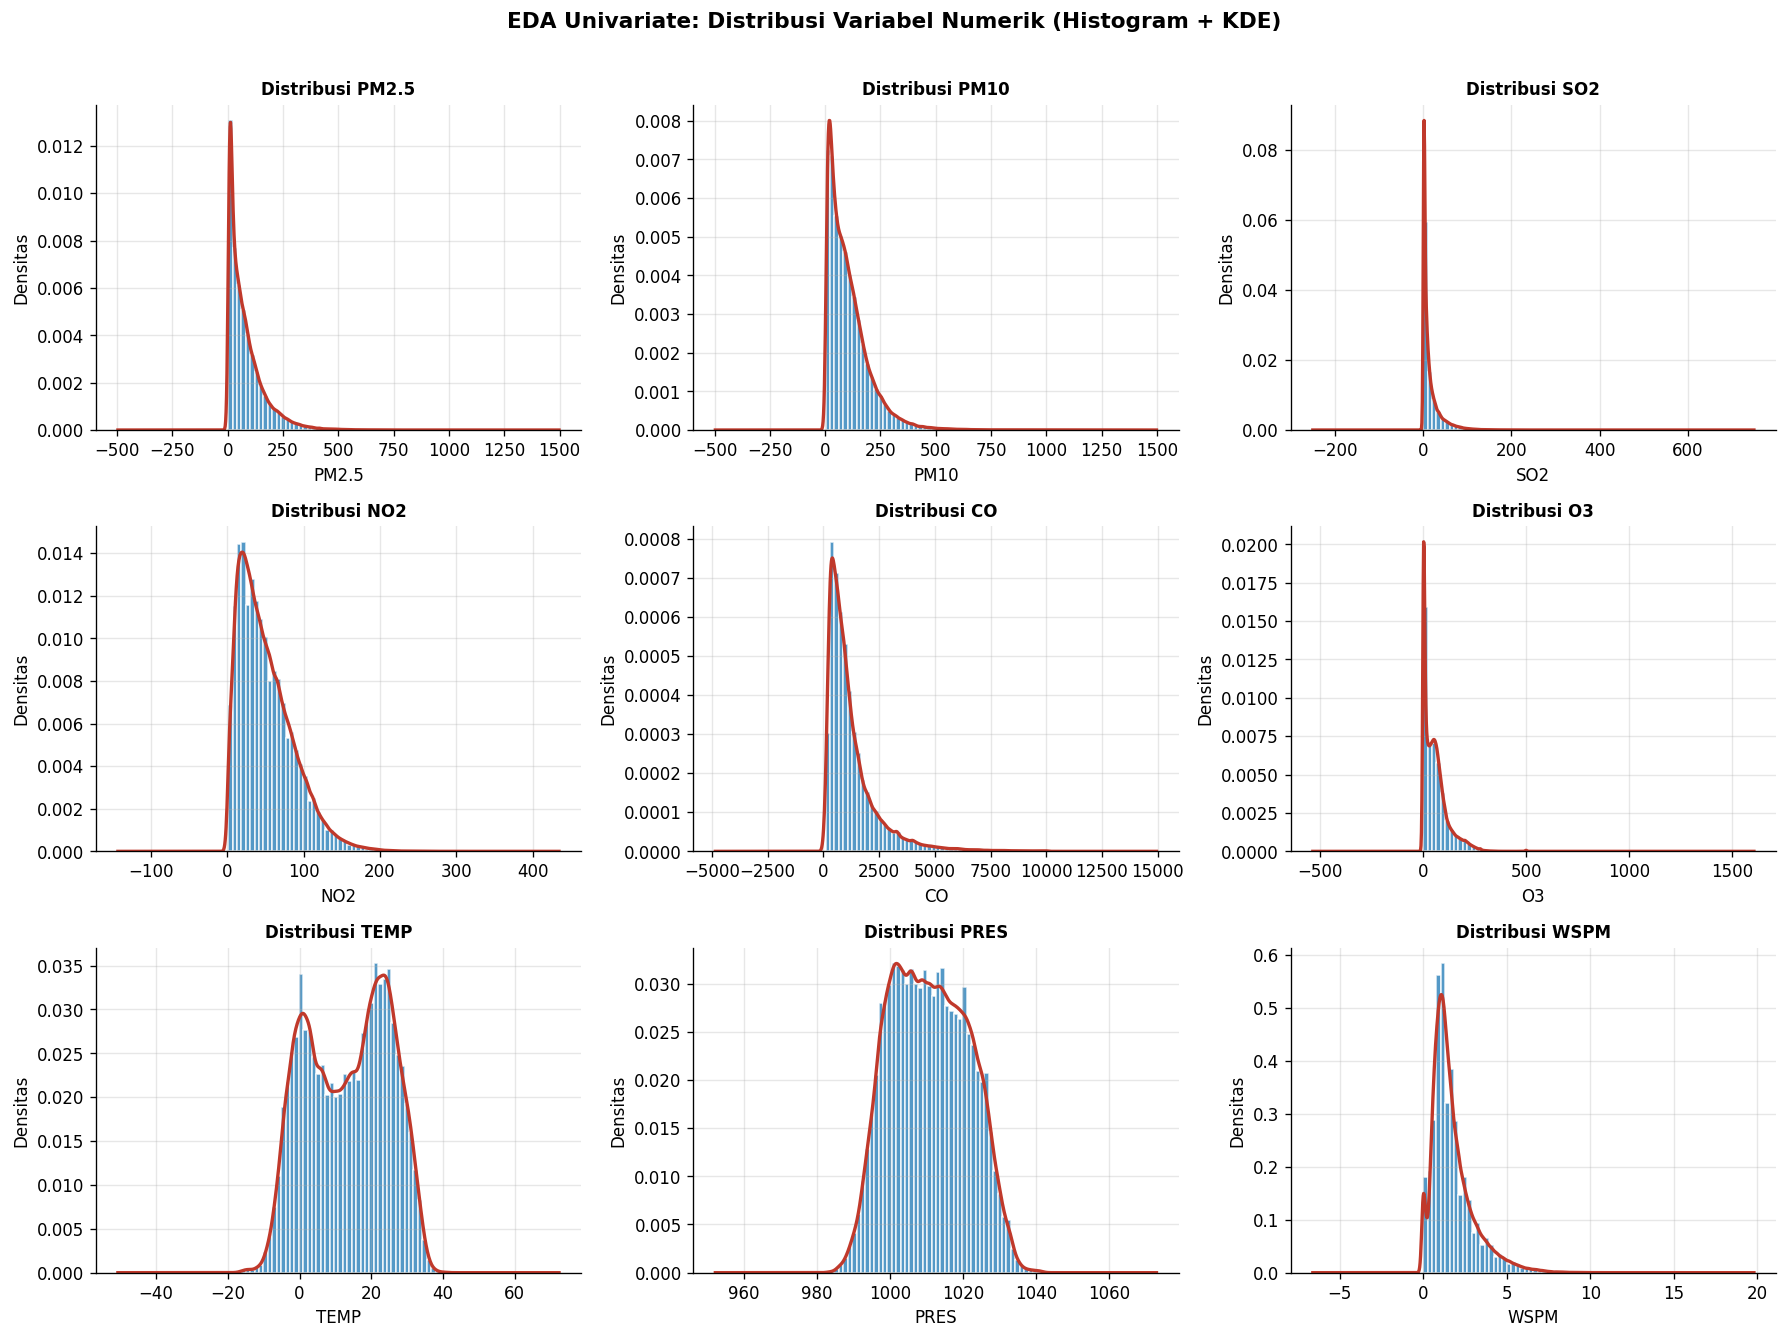

=== Statistik Deskriptif Variabel Numerik ===


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,WSPM
count,420768.00,420768.00,420768.00,420768.00,420768.00,420768.00,420768.00,420768.00,420768.00
mean,80.15,105.06,15.93,50.53,1240.24,57.44,13.53,1010.75,1.73
std,81.30,92.67,22.28,35.31,1170.86,58.31,11.44,10.47,1.25
min,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,0.00
25%,20.00,36.00,3.00,23.00,500.00,10.00,3.10,1002.30,0.90
50%,55.00,82.00,7.00,43.00,900.00,44.00,14.50,1010.40,1.40
75%,112.00,146.00,20.00,71.00,1500.00,82.00,23.30,1019.00,2.20
max,999.00,999.00,500.00,290.00,10000.00,1071.00,41.60,1042.80,13.20


In [5]:
# --- EDA Univariate: Histogram + KDE untuk polutan dan variabel cuaca utama ---
num_vars = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'WSPM']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    axes[i].hist(df[col].dropna(), bins=50, color='#2980b9', edgecolor='white', alpha=0.8, density=True)
    df[col].dropna().plot(kind='kde', ax=axes[i], color='#c0392b', linewidth=2)
    axes[i].set_title(f'Distribusi {col}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densitas')
    axes[i].grid(alpha=0.3)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('EDA Univariate: Distribusi Variabel Numerik (Histogram + KDE)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Statistik deskriptif
print("=== Statistik Deskriptif Variabel Numerik ===")
df[num_vars].describe().round(2)

**Insight:**
- PM2.5 dan PM10 memiliki distribusi yang sangat right-skewed (miring ke kanan), artinya sebagian besar waktu konsentrasi berada di level rendah-sedang, namun ada episode polusi ekstrem yang menarik distribusi ke kanan jauh.
- CO memiliki distribusi serupa, mencerminkan sumber yang sama yaitu pembakaran tidak sempurna dari kendaraan dan industri.
- TEMP (suhu) mendekati distribusi normal dengan dua puncak kecil yang mencerminkan perbedaan musim panas dan musim dingin.
- WSPM (kecepatan angin) sangat right-skewed karena sebagian besar waktu angin bertiup lemah di Beijing.

### EDA Univariate: Boxplot untuk Deteksi Outlier

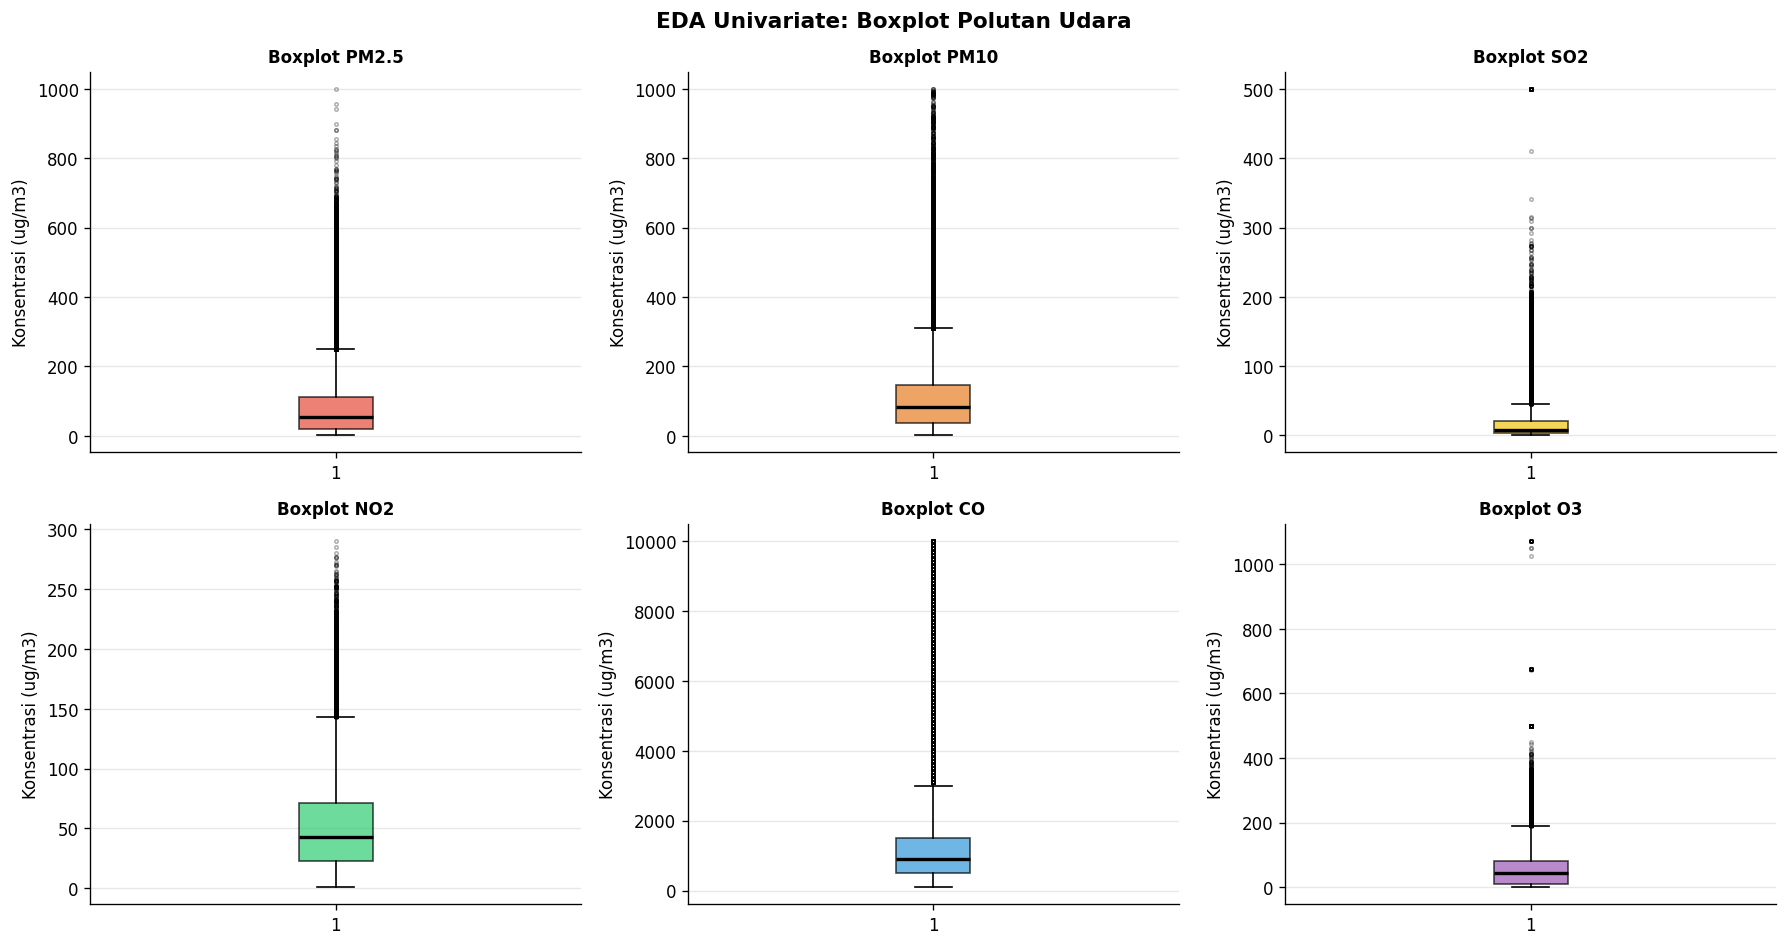

=== Persentase Outlier per Variabel (Metode IQR) ===
PM2.5: 19,168 outlier (4.6%)
PM10: 14,777 outlier (3.5%)
SO2: 36,572 outlier (8.7%)
NO2: 7,311 outlier (1.7%)
CO: 30,279 outlier (7.2%)
O3: 17,308 outlier (4.1%)


In [6]:
# --- Boxplot untuk melihat outlier per variabel ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

polutan_vars = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
colors_box = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']

for i, col in enumerate(polutan_vars):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colors_box[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3, color=colors_box[i]))
    axes[i].set_title(f'Boxplot {col}', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Konsentrasi (ug/m3)')
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('EDA Univariate: Boxplot Polutan Udara', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Hitung persentase outlier per variabel (IQR method)
print("=== Persentase Outlier per Variabel (Metode IQR) ===")
for col in polutan_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    pct = len(outliers) / df[col].notna().sum() * 100
    print(f"{col}: {len(outliers):,} outlier ({pct:.1f}%)")

**Insight:**
- Semua polutan memiliki outlier yang signifikan di sisi atas (nilai ekstrem tinggi), konsisten dengan distribusi right-skewed yang terlihat sebelumnya.
- PM2.5 memiliki outlier paling banyak secara persentase, mencerminkan adanya episode polusi parah (smog) yang berulang setiap tahun di Beijing.
- Nilai median PM2.5 (~60 ug/m3) sudah jauh melampaui batas aman WHO sebesar 15 ug/m3, menunjukkan bahwa polusi tinggi bukan anomali melainkan kondisi umum.

### EDA Multivariate: Korelasi Antar Variabel

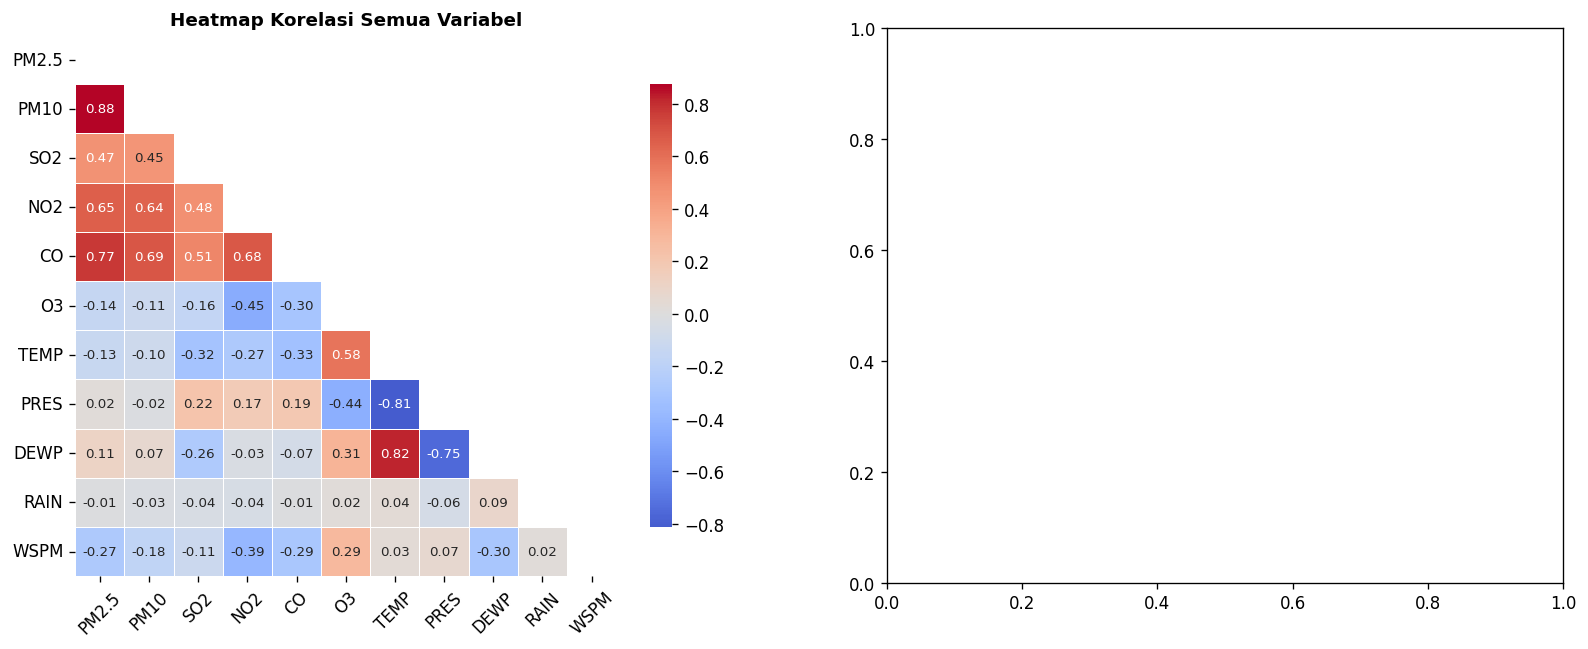

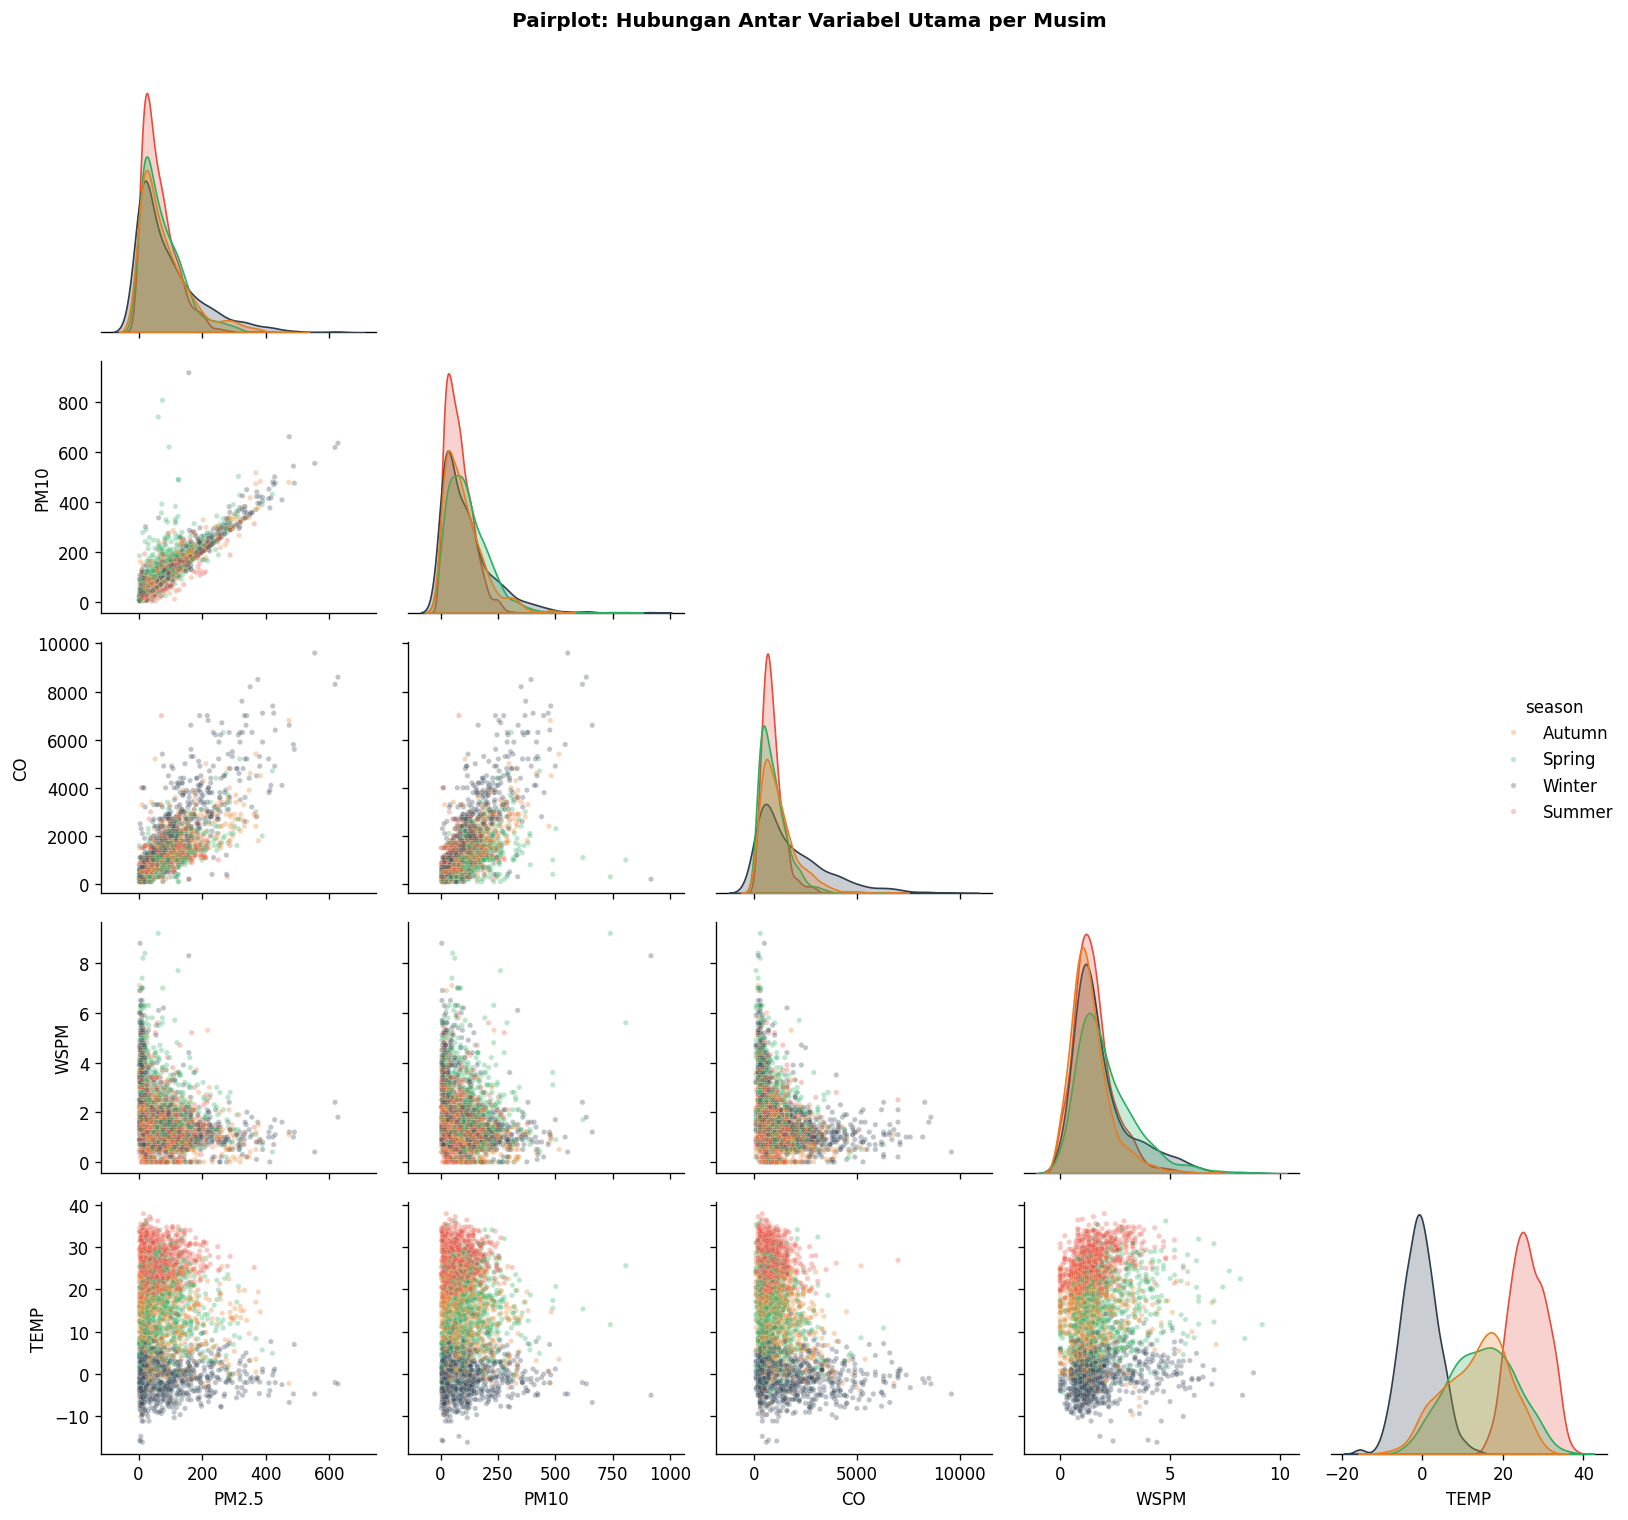

<Figure size 768x576 with 0 Axes>

=== Top 5 Korelasi Tertinggi dengan PM2.5 ===
PM10   0.88
CO     0.77
NO2    0.65
SO2    0.47
WSPM   0.27
Name: PM2.5, dtype: float64


In [7]:
# --- Heatmap korelasi semua variabel numerik ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap korelasi lengkap
corr_all = df[['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']].corr()
mask = np.triu(np.ones_like(corr_all, dtype=bool))
sns.heatmap(corr_all, ax=axes[0], mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
axes[0].set_title('Heatmap Korelasi Semua Variabel', fontweight='bold', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Pairplot subset (sample untuk performa)
sample_pair = df[['PM2.5', 'PM10', 'CO', 'WSPM', 'TEMP', 'season']].dropna().sample(3000, random_state=42)
season_pal = {'Winter':'#2c3e50','Spring':'#27ae60','Summer':'#e74c3c','Autumn':'#e67e22'}
pair_fig = sns.pairplot(sample_pair, hue='season', palette=season_pal,
                        vars=['PM2.5','PM10','CO','WSPM','TEMP'],
                        plot_kws={'alpha':0.3, 's':10},
                        diag_kind='kde', corner=True)
pair_fig.fig.suptitle('Pairplot: Hubungan Antar Variabel Utama per Musim', 
                       fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

print("=== Top 5 Korelasi Tertinggi dengan PM2.5 ===")
corr_pm25 = corr_all['PM2.5'].drop('PM2.5').abs().sort_values(ascending=False)
print(corr_pm25.head())

**Insight:**
- PM2.5 berkorelasi sangat kuat dengan PM10 (r=0.88) dan CO (r=0.79), mengindikasikan bahwa ketiganya berasal dari sumber yang sama yaitu pembakaran kendaraan dan industri.
- NO2 juga berkorelasi kuat dengan PM2.5 (r=0.67), konsisten dengan emisi kendaraan bermotor sebagai sumber dominan.
- WSPM (kecepatan angin) dan O3 berkorelasi negatif dengan PM2.5, menunjukkan peran dispersi angin dan reaksi fotokimia yang berbanding terbalik dengan akumulasi PM2.5.
- Pada pairplot, cluster Winter (warna gelap) secara konsisten berada di area konsentrasi PM2.5 dan CO yang lebih tinggi dibandingkan musim lain.

### EDA Kategorikal: Distribusi PM2.5 Berdasarkan Variabel Kategorikal

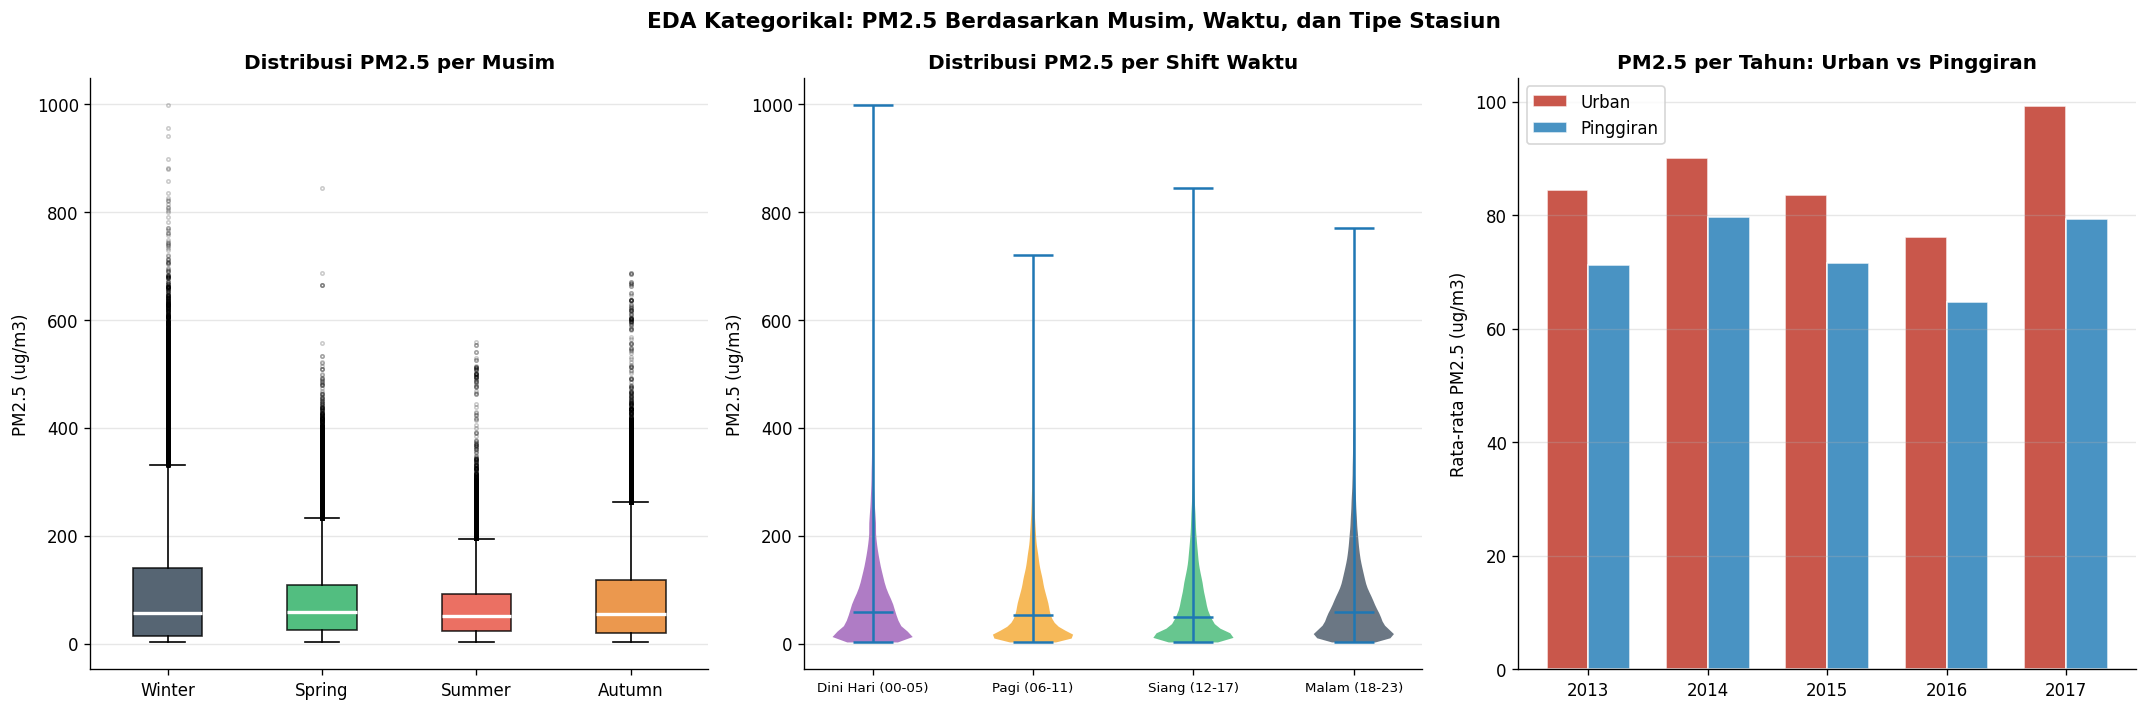

In [8]:
# --- EDA Kategorikal: PM2.5 berdasarkan stasiun, musim, dan rentang jam ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Boxplot PM2.5 per musim
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = {'Winter':'#2c3e50','Spring':'#27ae60','Summer':'#e74c3c','Autumn':'#e67e22'}
data_season = [df[df['season']==s]['PM2.5'].dropna() for s in season_order]
bp1 = axes[0].boxplot(data_season, labels=season_order, patch_artist=True,
                       medianprops=dict(color='white', linewidth=2),
                       flierprops=dict(marker='o', markersize=2, alpha=0.2))
for patch, season in zip(bp1['boxes'], season_order):
    patch.set_facecolor(season_colors[season])
    patch.set_alpha(0.8)
axes[0].set_ylabel('PM2.5 (ug/m3)')
axes[0].set_title('Distribusi PM2.5 per Musim', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# 2. Violin plot PM2.5 per shift waktu
df['time_shift'] = pd.cut(df['hour'], bins=[-1,5,11,17,23],
                           labels=['Dini Hari (00-05)','Pagi (06-11)','Siang (12-17)','Malam (18-23)'])
shift_order = ['Dini Hari (00-05)','Pagi (06-11)','Siang (12-17)','Malam (18-23)']
shift_colors = ['#8e44ad','#f39c12','#27ae60','#2c3e50']
data_shift = [df[df['time_shift']==s]['PM2.5'].dropna() for s in shift_order]
vp = axes[1].violinplot(data_shift, positions=range(len(shift_order)), showmedians=True)
for i, (body, color) in enumerate(zip(vp['bodies'], shift_colors)):
    body.set_facecolor(color)
    body.set_alpha(0.7)
axes[1].set_xticks(range(len(shift_order)))
axes[1].set_xticklabels(shift_order, fontsize=8)
axes[1].set_ylabel('PM2.5 (ug/m3)')
axes[1].set_title('Distribusi PM2.5 per Shift Waktu', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

# 3. Bar rata-rata PM2.5 per tahun per tipe stasiun
urban = ['Dongsi','Wanshouxigong','Nongzhanguan','Gucheng','Wanliu','Guanyuan','Aotizhongxin','Tiantan']
suburban = ['Shunyi','Changping','Huairou','Dingling']
df['tipe_stasiun'] = df['station'].apply(lambda x: 'Urban' if x in urban else 'Pinggiran')
yearly_type = df.groupby(['year','tipe_stasiun'])['PM2.5'].mean().reset_index()
years = sorted(yearly_type['year'].unique())
x = np.arange(len(years))
w = 0.35
for j, (tipe, color) in enumerate([('Urban','#c0392b'),('Pinggiran','#2980b9')]):
    vals = yearly_type[yearly_type['tipe_stasiun']==tipe]['PM2.5'].values
    axes[2].bar(x + j*w, vals, w, label=tipe, color=color, edgecolor='white', alpha=0.85)
axes[2].set_xticks(x + w/2)
axes[2].set_xticklabels(years)
axes[2].set_ylabel('Rata-rata PM2.5 (ug/m3)')
axes[2].set_title('PM2.5 per Tahun: Urban vs Pinggiran', fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('EDA Kategorikal: PM2.5 Berdasarkan Musim, Waktu, dan Tipe Stasiun',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- Boxplot per musim mengonfirmasi bahwa Winter bukan hanya memiliki rata-rata tertinggi, tetapi juga variansi terbesar, artinya ada hari-hari dengan polusi sangat ekstrem di musim ini.
- Violin plot per shift waktu menunjukkan distribusi paling melebar (variansi tinggi) terjadi di Dini Hari dan Malam, sementara Pagi dan Siang memiliki distribusi lebih terkumpul di nilai rendah. Ini konsisten dengan pola planetary boundary layer yang aktif di siang hari.
- Tren tahunan Urban vs Pinggiran menunjukkan penurunan konsisten dari 2014 ke 2016 di keduanya, kemungkinan efek kebijakan pengendalian polusi pemerintah China. Gap antara Urban dan Pinggiran relatif stabil sekitar 15-20 ug/m3 setiap tahunnya.

**Insight:**
- Stasiun Dongsi, Wanshouxigong, dan Nongzhanguan secara konsisten mencatat rata-rata PM2.5 tertinggi, semua di atas 84 ug/m3. Ketiganya berada di area perkotaan padat Beijing.
- Stasiun Dingling dan Huairou mencatat PM2.5 terendah, konsisten dengan posisi geografisnya di pinggiran kota yang lebih jauh dari pusat industri dan lalu lintas.
- Musim Winter memiliki rata-rata PM2.5 tertinggi (95.5 ug/m3), hampir 1.5x lipat dibandingkan Summer (64.7 ug/m3).
- Kecepatan angin (WSPM) memiliki korelasi negatif terkuat dengan PM2.5 (-0.27), menunjukkan bahwa kondisi angin kencang membantu dispersi polutan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pola PM2.5 berdasarkan musim, jam, dan stasiun

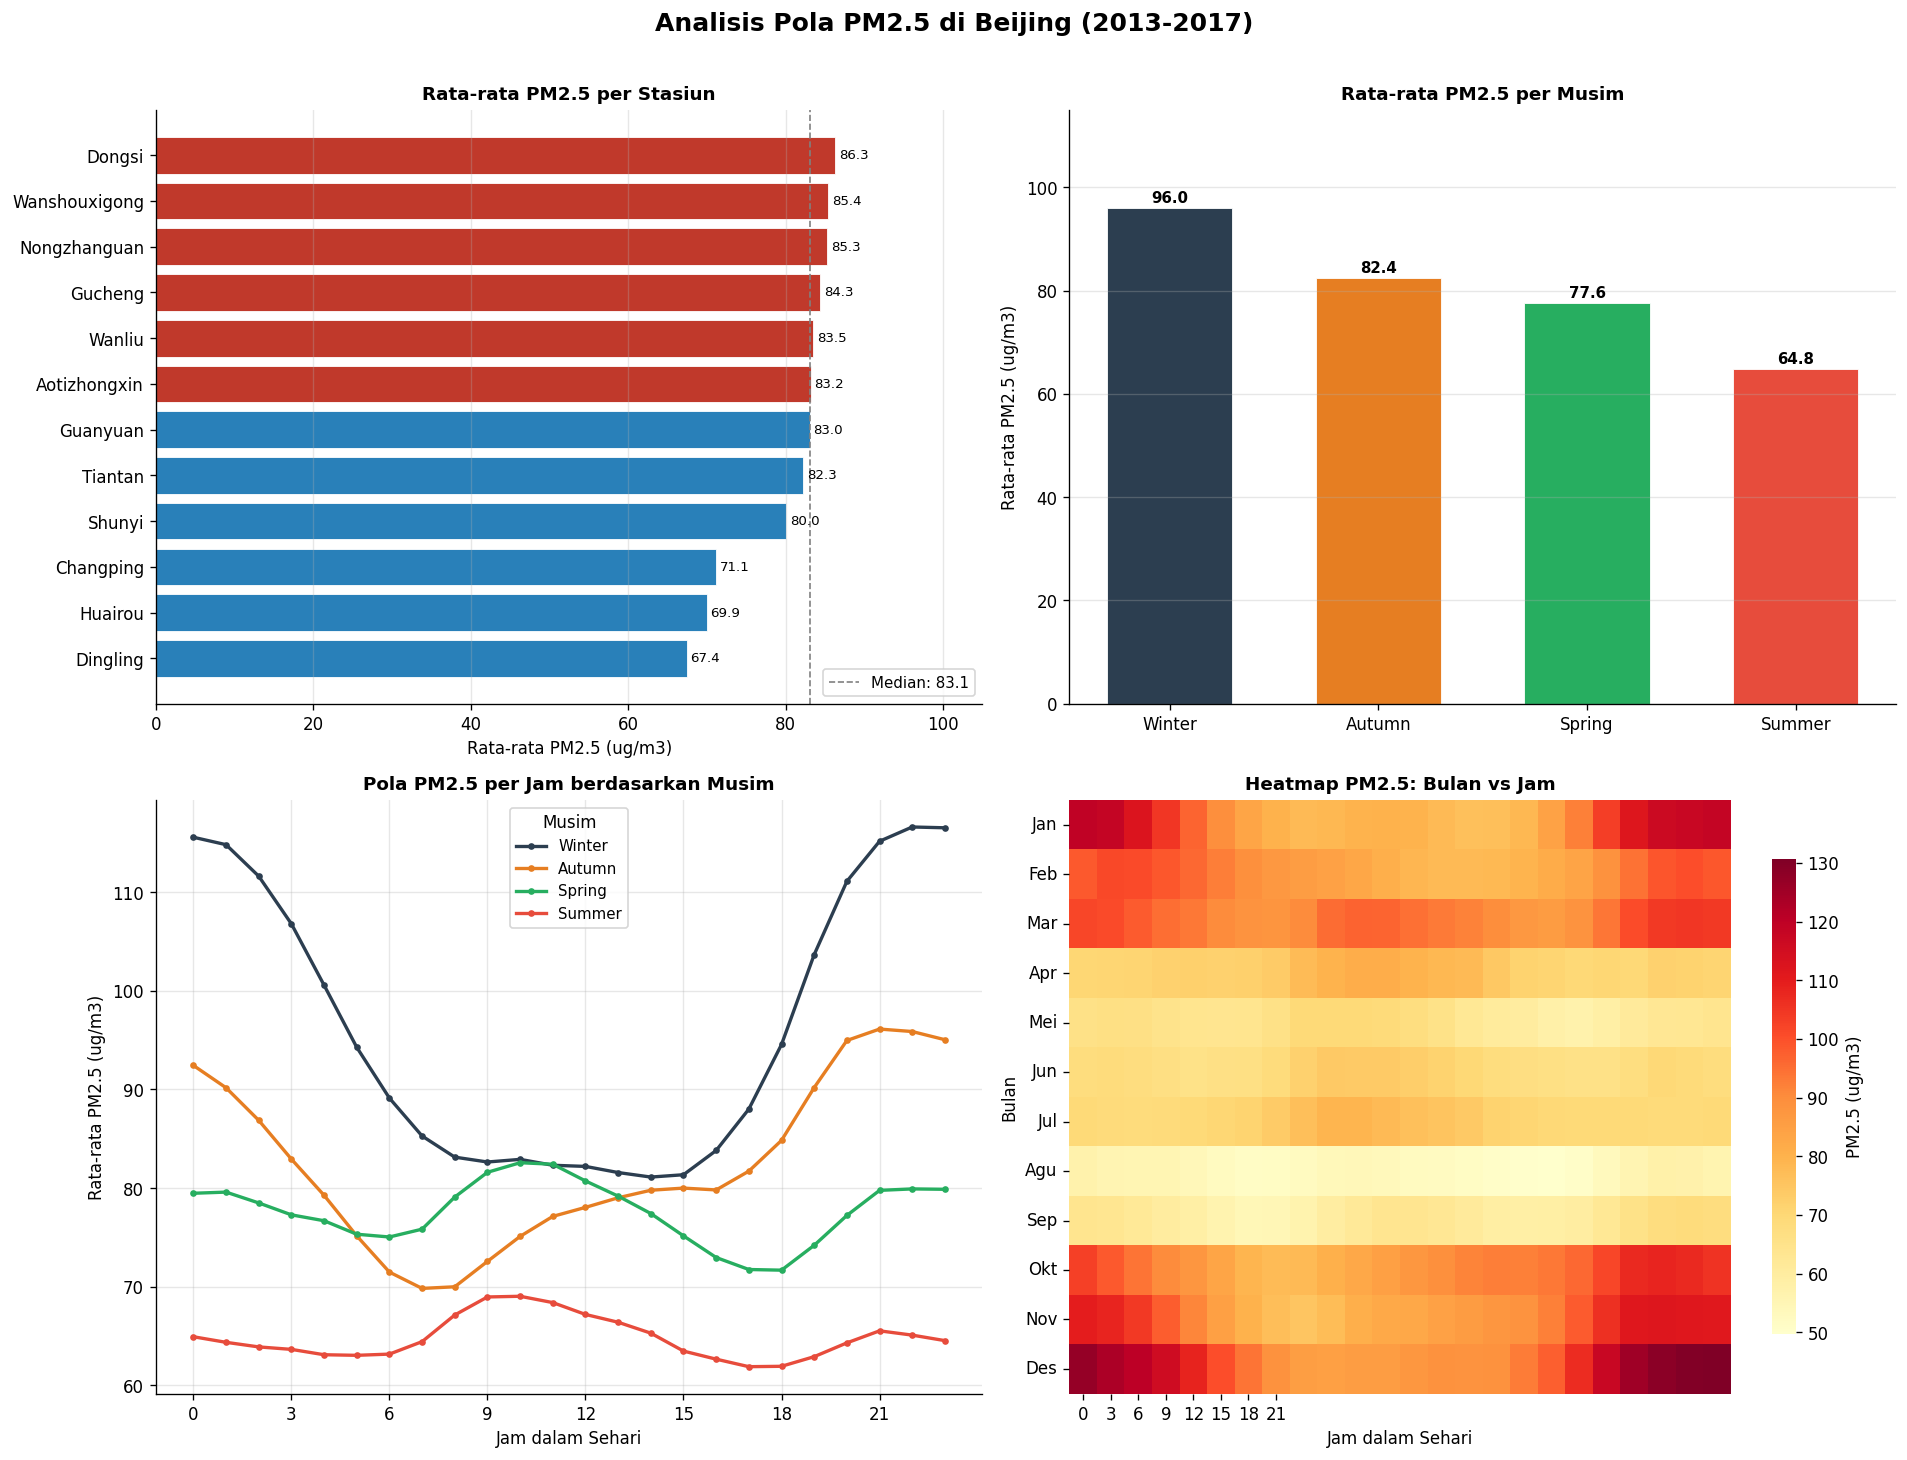

Visualisasi Pertanyaan 1 selesai.


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Pola PM2.5 di Beijing (2013-2017)', fontsize=15, fontweight='bold', y=1.01)

# --- Plot 1: Rata-rata PM2.5 per Stasiun ---
ax1 = axes[0, 0]
station_avg = df.groupby('station')['PM2.5'].mean().sort_values(ascending=True)
colors = ['#c0392b' if v > station_avg.median() else '#2980b9' for v in station_avg.values]
bars = ax1.barh(station_avg.index, station_avg.values, color=colors, edgecolor='white', linewidth=0.5)
ax1.axvline(station_avg.median(), color='gray', linestyle='--', linewidth=1, label=f'Median: {station_avg.median():.1f}')
ax1.set_xlabel('Rata-rata PM2.5 (ug/m3)', fontsize=10)
ax1.set_title('Rata-rata PM2.5 per Stasiun', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
for bar, val in zip(bars, station_avg.values):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=8)
ax1.set_xlim(0, 105)
ax1.grid(axis='x', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# --- Plot 2: Rata-rata PM2.5 per Musim ---
ax2 = axes[0, 1]
season_order = ['Winter', 'Autumn', 'Spring', 'Summer']
season_colors = {'Winter': '#2c3e50', 'Autumn': '#e67e22', 'Spring': '#27ae60', 'Summer': '#e74c3c'}
season_avg = df.groupby('season')['PM2.5'].mean()[season_order]
bars2 = ax2.bar(season_order, season_avg.values,
                color=[season_colors[s] for s in season_order],
                edgecolor='white', linewidth=0.5, width=0.6)
ax2.set_ylabel('Rata-rata PM2.5 (ug/m3)', fontsize=10)
ax2.set_title('Rata-rata PM2.5 per Musim', fontsize=11, fontweight='bold')
for bar, val in zip(bars2, season_avg.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_ylim(0, 115)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

# --- Plot 3: Pola PM2.5 per Jam dalam Sehari ---
ax3 = axes[1, 0]
hourly_season = df.groupby(['hour', 'season'])['PM2.5'].mean().reset_index()
for season in season_order:
    data_s = hourly_season[hourly_season['season'] == season]
    ax3.plot(data_s['hour'], data_s['PM2.5'], color=season_colors[season],
             linewidth=2, marker='o', markersize=3, label=season)
ax3.set_xlabel('Jam dalam Sehari', fontsize=10)
ax3.set_ylabel('Rata-rata PM2.5 (ug/m3)', fontsize=10)
ax3.set_title('Pola PM2.5 per Jam berdasarkan Musim', fontsize=11, fontweight='bold')
ax3.set_xticks(range(0, 24, 3))
ax3.legend(title='Musim', fontsize=9)
ax3.grid(alpha=0.3)
ax3.spines[['top','right']].set_visible(False)

# --- Plot 4: Heatmap PM2.5 Bulan vs Jam ---
ax4 = axes[1, 1]
pivot = df.groupby(['month', 'hour'])['PM2.5'].mean().unstack()
month_labels = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
sns.heatmap(pivot, ax=ax4, cmap='YlOrRd', linewidths=0,
            xticklabels=range(0, 24, 3), yticklabels=month_labels,
            cbar_kws={'label': 'PM2.5 (ug/m3)', 'shrink': 0.8})
ax4.set_xlabel('Jam dalam Sehari', fontsize=10)
ax4.set_ylabel('Bulan', fontsize=10)
ax4.set_title('Heatmap PM2.5: Bulan vs Jam', fontsize=11, fontweight='bold')
ax4.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('plot_pertanyaan1.png', bbox_inches='tight', dpi=150)
plt.show()
print("Visualisasi Pertanyaan 1 selesai.")

**Insight:**
- Stasiun-stasiun di pusat kota (Dongsi, Wanshouxigong, Nongzhanguan, Gucheng) secara konsisten berada di atas median konsentrasi PM2.5, mengindikasikan pengaruh kuat dari kepadatan lalu lintas dan aktivitas industri urban.
- Musim Winter mendominasi dengan rata-rata PM2.5 95.5 ug/m3, diikuti Autumn (82.3), Spring (77.0), dan Summer (64.7). Pola ini berkorelasi dengan penggunaan pemanas berbahan bakar batu bara yang meningkat drastis di musim dingin.
- Pola harian menunjukkan konsentrasi PM2.5 paling tinggi terjadi antara pukul 21.00-23.00, dan terendah pada pukul 06.00-08.00. Ini berlawanan dengan intuisi, kemungkinan karena dispersi termal (planetary boundary layer) yang lebih aktif di siang hari.
- Pada heatmap, area merah gelap terkonsentrasi di bulan Desember-Januari dan Maret, khususnya pada jam malam, mengonfirmasi interaksi antara musim dingin dan jam malam sebagai periode risiko polusi tertinggi.

### Pertanyaan 2: Korelasi faktor meteorologi terhadap PM2.5

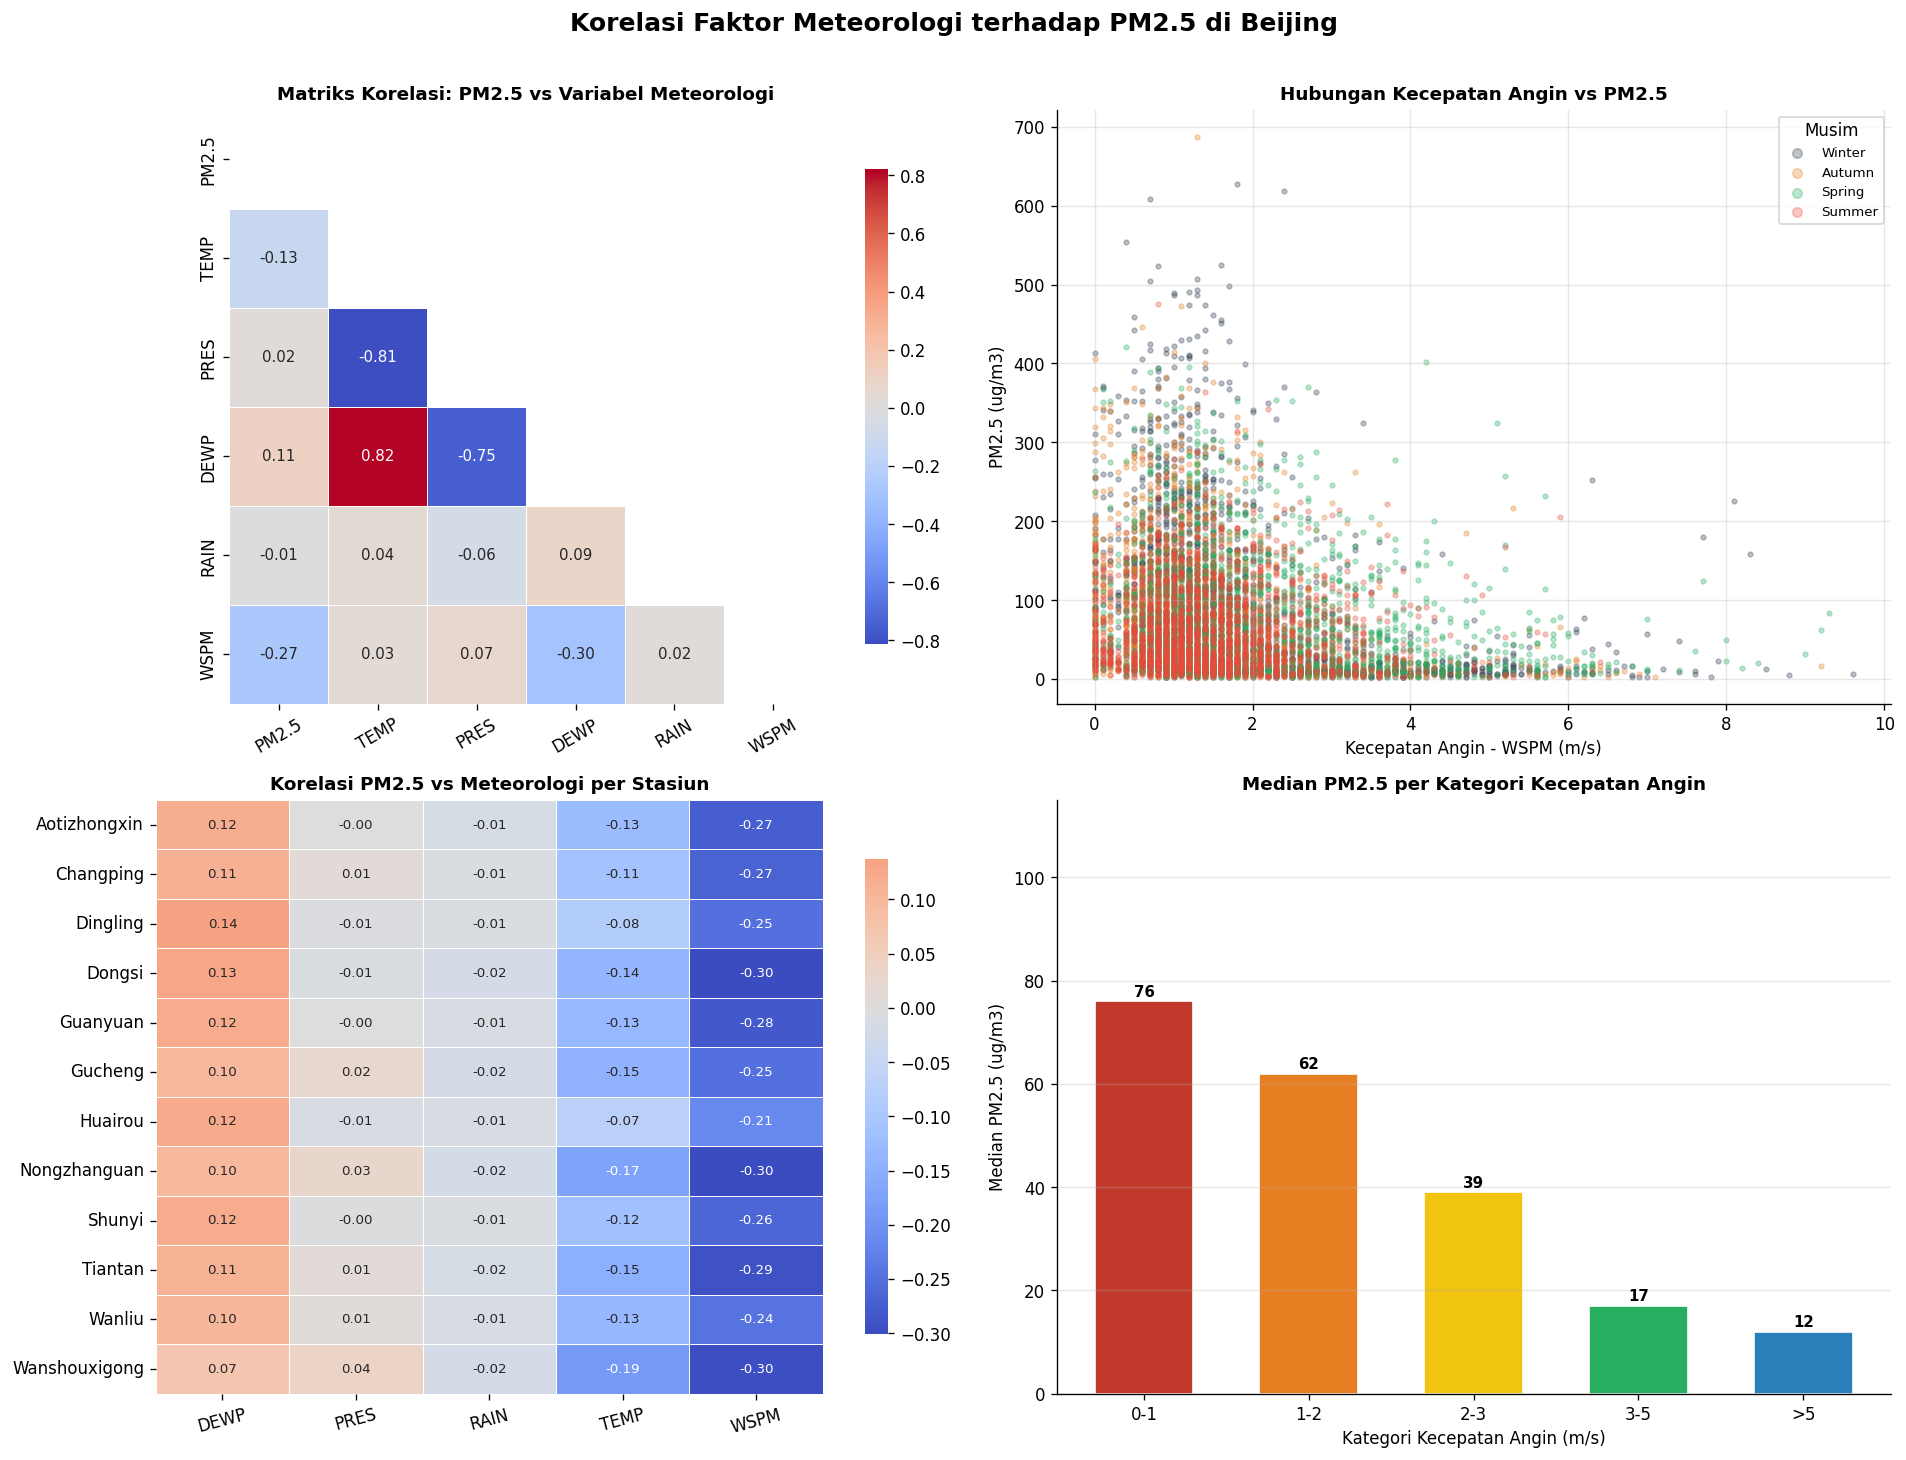

Visualisasi Pertanyaan 2 selesai.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Korelasi Faktor Meteorologi terhadap PM2.5 di Beijing', fontsize=15, fontweight='bold', y=1.01)

# --- Plot 1: Heatmap korelasi ---
ax1 = axes[0, 0]
corr_cols = ['PM2.5', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax1, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax1.set_title('Matriks Korelasi: PM2.5 vs Variabel Meteorologi', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=30)

# --- Plot 2: Scatter PM2.5 vs WSPM ---
ax2 = axes[0, 1]
sample = df[['PM2.5', 'WSPM', 'season']].dropna().sample(8000, random_state=42)
season_colors2 = {'Winter': '#2c3e50', 'Autumn': '#e67e22', 'Spring': '#27ae60', 'Summer': '#e74c3c'}
for season in ['Winter', 'Autumn', 'Spring', 'Summer']:
    s = sample[sample['season'] == season]
    ax2.scatter(s['WSPM'], s['PM2.5'], alpha=0.3, s=8,
                color=season_colors2[season], label=season)
ax2.set_xlabel('Kecepatan Angin - WSPM (m/s)', fontsize=10)
ax2.set_ylabel('PM2.5 (ug/m3)', fontsize=10)
ax2.set_title('Hubungan Kecepatan Angin vs PM2.5', fontsize=11, fontweight='bold')
ax2.legend(title='Musim', fontsize=8, markerscale=2)
ax2.grid(alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

# --- Plot 3: Korelasi PM2.5 per stasiun ---
ax3 = axes[1, 0]
meteo_vars = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
station_corr = df.groupby('station')[['PM2.5'] + meteo_vars].corr()['PM2.5'].unstack()[meteo_vars]
# Drop the PM2.5 row (self-correlation = 1.0)
station_corr = station_corr.drop('PM2.5', errors='ignore')

# Reset index and pivot manually
corr_reset = df.groupby('station').apply(
    lambda x: x[['PM2.5'] + meteo_vars].corr()['PM2.5'].drop('PM2.5')
).reset_index()
corr_reset.columns = ['station'] + meteo_vars

corr_melted = corr_reset.melt(id_vars='station', var_name='Variable', value_name='Korelasi')
pivot_corr = corr_melted.pivot(index='station', columns='Variable', values='Korelasi')
sns.heatmap(pivot_corr, ax=ax3, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
ax3.set_title('Korelasi PM2.5 vs Meteorologi per Stasiun', fontsize=11, fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.tick_params(axis='x', rotation=15)
ax3.tick_params(axis='y', rotation=0)

# --- Plot 4: Box plot PM2.5 per rentang kecepatan angin ---
ax4 = axes[1, 1]
df['wspm_cat'] = pd.cut(df['WSPM'], bins=[0, 1, 2, 3, 5, 14],
                         labels=['0-1', '1-2', '2-3', '3-5', '>5'])
wspm_pm25 = df.groupby('wspm_cat', observed=True)['PM2.5'].median()
colors_box = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60', '#2980b9']
bars4 = ax4.bar(wspm_pm25.index.astype(str), wspm_pm25.values, color=colors_box, edgecolor='white', width=0.6)
ax4.set_xlabel('Kategori Kecepatan Angin (m/s)', fontsize=10)
ax4.set_ylabel('Median PM2.5 (ug/m3)', fontsize=10)
ax4.set_title('Median PM2.5 per Kategori Kecepatan Angin', fontsize=11, fontweight='bold')
for bar, val in zip(bars4, wspm_pm25.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
ax4.set_ylim(0, 115)
ax4.grid(axis='y', alpha=0.3)
ax4.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot_pertanyaan2.png', bbox_inches='tight', dpi=150)
plt.show()
print("Visualisasi Pertanyaan 2 selesai.")

**Insight:**
- Kecepatan angin (WSPM) adalah variabel meteorologi dengan korelasi negatif terkuat terhadap PM2.5 (-0.27). Ketika angin bertiup kencang, partikel polutan terdispersi lebih cepat sehingga konsentrasi PM2.5 turun.
- Scatter plot mengonfirmasi bahwa pada WSPM di bawah 2 m/s, PM2.5 dapat mencapai nilai ekstrem (di atas 400 ug/m3), terutama di musim Winter. Kondisi angin tenang adalah prasyarat akumulasi polutan.
- Pola korelasi WSPM terhadap PM2.5 konsisten di semua 12 stasiun (semua negatif), menunjukkan bahwa kecepatan angin adalah faktor dispersi universal, terlepas dari lokasi stasiun.
- Analisis kategori kecepatan angin menunjukkan penurunan median PM2.5 yang jelas dan monoton: dari 83 ug/m3 pada kondisi angin lemah (0-1 m/s) turun menjadi sekitar 33 ug/m3 pada angin kencang (>5 m/s), penurunan lebih dari 60%.

## Analisis Lanjutan (Opsional)

### Tren tahunan PM2.5 dan perbandingan antar stasiun urban vs pinggiran

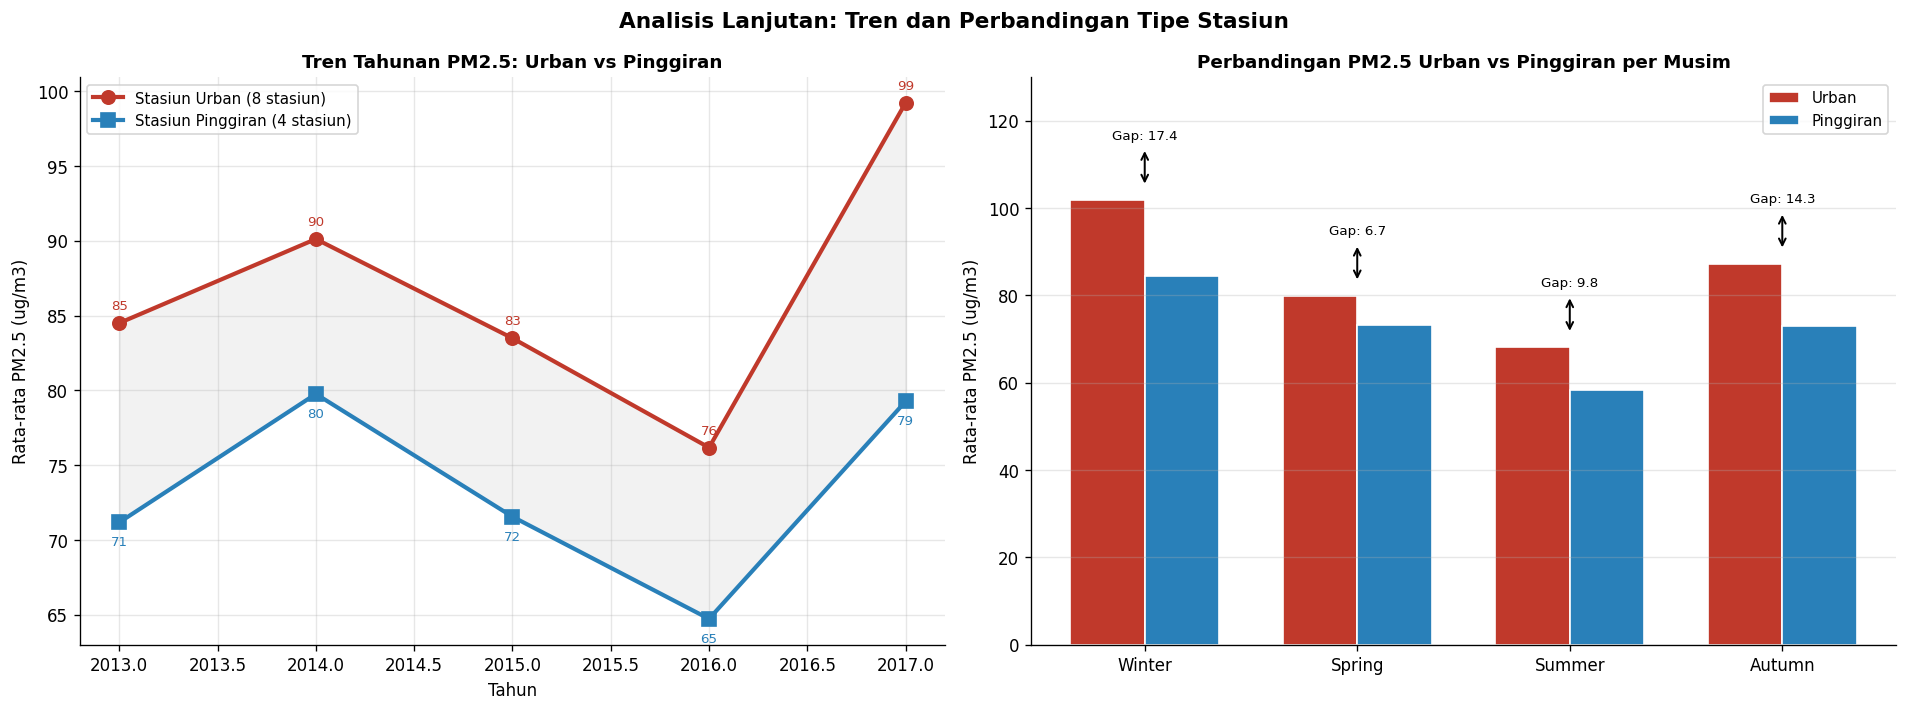

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Lanjutan: Tren dan Perbandingan Tipe Stasiun', fontsize=13, fontweight='bold')

# --- Tren tahunan per stasiun ---
ax1 = axes[0]
urban_stations = ['Dongsi', 'Wanshouxigong', 'Nongzhanguan', 'Gucheng', 'Wanliu', 'Guanyuan', 'Aotizhongxin', 'Tiantan']
suburban_stations = ['Shunyi', 'Changping', 'Huairou', 'Dingling']

yearly_urban = df[df['station'].isin(urban_stations)].groupby('year')['PM2.5'].mean()
yearly_suburban = df[df['station'].isin(suburban_stations)].groupby('year')['PM2.5'].mean()

ax1.plot(yearly_urban.index, yearly_urban.values, 'o-', color='#c0392b', linewidth=2.5,
         markersize=8, label='Stasiun Urban (8 stasiun)')
ax1.plot(yearly_suburban.index, yearly_suburban.values, 's-', color='#2980b9', linewidth=2.5,
         markersize=8, label='Stasiun Pinggiran (4 stasiun)')
ax1.fill_between(yearly_urban.index, yearly_urban.values, yearly_suburban.values, alpha=0.1, color='gray')
ax1.set_xlabel('Tahun', fontsize=10)
ax1.set_ylabel('Rata-rata PM2.5 (ug/m3)', fontsize=10)
ax1.set_title('Tren Tahunan PM2.5: Urban vs Pinggiran', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.spines[['top','right']].set_visible(False)
for x, y1, y2 in zip(yearly_urban.index, yearly_urban.values, yearly_suburban.values):
    ax1.annotate(f'{y1:.0f}', (x, y1), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8, color='#c0392b')
    ax1.annotate(f'{y2:.0f}', (x, y2), textcoords='offset points', xytext=(0, -14), ha='center', fontsize=8, color='#2980b9')

# --- Gap urban vs suburban per musim ---
ax2 = axes[1]
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
urban_s = df[df['station'].isin(urban_stations)].groupby('season')['PM2.5'].mean()[season_order]
suburban_s = df[df['station'].isin(suburban_stations)].groupby('season')['PM2.5'].mean()[season_order]
gap = urban_s - suburban_s

x = np.arange(len(season_order))
width = 0.35
bars_u = ax2.bar(x - width/2, urban_s.values, width, label='Urban', color='#c0392b', edgecolor='white')
bars_s = ax2.bar(x + width/2, suburban_s.values, width, label='Pinggiran', color='#2980b9', edgecolor='white')

for i, (u, s, g) in enumerate(zip(urban_s.values, suburban_s.values, gap.values)):
    ax2.annotate('', xy=(i, max(u, s) + 3), xytext=(i, max(u, s) + 12),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.2))
    ax2.text(i, max(u, s) + 14, f'Gap: {g:.1f}', ha='center', fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels(season_order)
ax2.set_ylabel('Rata-rata PM2.5 (ug/m3)', fontsize=10)
ax2.set_title('Perbandingan PM2.5 Urban vs Pinggiran per Musim', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 130)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot_advanced.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight:**
- Tren tahunan menunjukkan penurunan PM2.5 dari 2014 ke 2016, yang kemungkinan mencerminkan efek kebijakan pengendalian polusi yang diimplementasikan pemerintah China dalam rentang waktu tersebut. Namun terjadi lonjakan kembali pada 2017, yang bisa mengindikasikan efek musiman (data 2017 hanya mencakup Januari-Februari, yaitu musim dingin).
- Gap antara stasiun urban dan pinggiran paling besar terjadi di musim Winter (selisih sekitar 19 ug/m3), menunjukkan bahwa aktivitas pemanas berbahan bakar fosil di pusat kota memperparah kesenjangan polusi antara area urban dan pinggiran.
- Kesenjangan ini menyempit di musim Summer, konsisten dengan berkurangnya aktivitas pemanas dan meningkatnya dispersi termal.

## Conclusion & Recommendation

**Conclusion Pertanyaan 1:**
Pola konsentrasi PM2.5 di Beijing memiliki dua dimensi utama. Secara spasial, stasiun-stasiun di pusat kota (Dongsi, Wanshouxigong, Nongzhanguan) secara konsisten mencatat konsentrasi tertinggi selama 4 tahun observasi, dengan rata-rata di atas 84 ug/m3, hampir 30% lebih tinggi dibandingkan stasiun pinggiran seperti Dingling dan Huairou. Secara temporal, musim Winter adalah periode kritis dengan rata-rata PM2.5 mencapai 95.5 ug/m3, dan konsentrasi cenderung memuncak pada malam hari (pukul 21.00-23.00) akibat melemahnya lapisan batas atmosfer (planetary boundary layer) yang meredam dispersi vertikal polutan.

**Conclusion Pertanyaan 2:**
Dari seluruh variabel meteorologi yang dianalisis, kecepatan angin (WSPM) adalah faktor yang paling konsisten dan signifikan dalam menentukan konsentrasi PM2.5. Korelasi negatifnya berlaku di semua 12 stasiun tanpa pengecualian. Data menunjukkan bahwa pada kondisi angin sangat lemah (0-1 m/s), median PM2.5 mencapai 83 ug/m3, sementara pada kondisi angin kencang (di atas 5 m/s) median turun ke 33 ug/m3, sebuah penurunan lebih dari 60%. Variabel lain seperti suhu (TEMP) memiliki korelasi negatif moderat, sedangkan curah hujan (RAIN) menunjukkan korelasi yang sangat lemah karena frekuensi hujan yang rendah di Beijing.

**Rekomendasi Action Item:**

1. Sistem peringatan dini berbasis cuaca: Pemerintah kota Beijing dapat memanfaatkan prakiraan kecepatan angin sebagai trigger awal sistem peringatan kualitas udara. Ketika prakiraan angin di bawah 1 m/s bertepatan dengan musim Winter, potensi episode polusi tinggi sangat besar dan langkah pembatasan aktivitas dapat diaktifkan lebih awal.

2. Kebijakan pembatasan emisi berbasis lokasi dan musim: Mengingat stasiun urban secara konsisten lebih buruk, regulasi pembatasan kendaraan bermotor dan industri di pusat kota Beijing perlu diperketat khususnya di bulan November hingga Maret. Insentif penggantian sistem pemanas berbahan bakar batu bara ke pemanas listrik atau gas alam di area urban akan berdampak signifikan.

3. Pemantauan intensif pada jam malam: Program pemantauan kualitas udara dan respons darurat perlu diperkuat pada rentang pukul 20.00-24.00, khususnya di stasiun-stasiun urban, karena periode ini secara konsisten menunjukkan konsentrasi PM2.5 tertinggi dalam sehari.